# PETE 689 Fundamentals of Fluids and Geomechanics — Homework 1


##  Problem 1

* **Ideal gas law**

$$PV = nRT$$


$$
\rho_{\text{ideal}} = \frac{m}{V} = \frac{PM}{RT}
$$


* **Peng–Robinson EOS**

$$
P =\frac{RT}{v-b}-\frac{a(T)}{v(v+b)+b(v-b)}
$$

$$
\rho_{\text{PR}} = \frac{M}{v}
$$



Where

$v$ is the the molar volume of the fluid

For each specified P,T, solve the PR EOS for $v$.

$$

a(T)=0.45724\frac{R^2T_c^2}{P_c}\left[1+\kappa\left(1-\sqrt{\frac{T}{T_c}}\right)\right]^2,

\kappa = 0.37464+1.54226\omega-0.26992\omega^2,

\qquad 
and 
\qquad 
b=0.07780\frac{RT_c}{P_c}
$$



### a)

In [18]:
import numpy as np
import matplotlib.pyplot as plt


R = 8.314  # J/mol/K

def celsius_to_kelvin(T_c):
    return T_c + 273.15


Tc_CH4_celcius = -82.5
Tc_CH4_kelvin = celsius_to_kelvin(Tc_CH4_celcius)

Tc_CO2_celcius = 31.0
Tc_CO2_kelvin = celsius_to_kelvin(Tc_CO2_celcius)


CH4 = dict(name="CH4", Tc=Tc_CH4_kelvin, Pc=4.6e6, omega=0.011, M=16e-3)  # kg/mol
CO2 = dict(name="CO2", Tc=Tc_CO2_kelvin, Pc=7.4e6, omega=0.228, M=44e-3)  # kg/mol

T_fixed = 80.0 + 273.15  # K
P_range = np.linspace(1e6, 20e6, 200)  # Pa (1–20 MPa)


rho_ideal = P_range * CH4["M"] / (R * T_fixed)  # kg/m^3

print(rho_ideal)

[  5.4494259    5.96972285   6.4900198    7.01031674   7.53061369
   8.05091063   8.57120758   9.09150452   9.61180147  10.13209842
  10.65239536  11.17269231  11.69298925  12.2132862   12.73358314
  13.25388009  13.77417704  14.29447398  14.81477093  15.33506787
  15.85536482  16.37566176  16.89595871  17.41625566  17.9365526
  18.45684955  18.97714649  19.49744344  20.01774038  20.53803733
  21.05833427  21.57863122  22.09892817  22.61922511  23.13952206
  23.659819    24.18011595  24.70041289  25.22070984  25.74100679
  26.26130373  26.78160068  27.30189762  27.82219457  28.34249151
  28.86278846  29.38308541  29.90338235  30.4236793   30.94397624
  31.46427319  31.98457013  32.50486708  33.02516403  33.54546097
  34.06575792  34.58605486  35.10635181  35.62664875  36.1469457
  36.66724265  37.18753959  37.70783654  38.22813348  38.74843043
  39.26872737  39.78902432  40.30932126  40.82961821  41.34991516
  41.8702121   42.39050905  42.91080599  43.43110294  43.95139988
  44.4716968

### b)

In [19]:
def pr_a_b(T, Tc, Pc, omega, R=8.314):
    """
    Return a(T) and b for Peng–Robinson EOS.
    """
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    Tr = T / Tc
    alpha = (1.0 + kappa*(1.0 - np.sqrt(Tr)))**2
    
    a = 0.45724 * (R**2 * Tc**2 / Pc) * alpha
    b = 0.07780 * (R * Tc / Pc)
    return a, b


def pr_pressure(v, T, a, b, R=8.314):
    """PR EOS: P(v) at given T, a, b."""
    return R*T/(v - b) - a/(v*(v + b) + b*(v - b))

def solve_v_pr_bisect(P, T, a, b, R=8.314, tol=1e-10, max_iter=200):
    """
    Solve for molar volume v (m^3/mol) given P,T using bisection on:
        f(v) = PR_P(v) - P = 0
    Assumes gas/supercritical single root (true for this HW's methane at 80°C).
    """
    # lower bound must be > b
    v_low = b * (1.0 + 1e-9)
    f_low = pr_pressure(v_low, T, a, b, R) - P

    # start upper bound near ideal-gas molar volume
    v_high = R*T/P
    f_high = pr_pressure(v_high, T, a, b, R) - P

    # If not bracketed, expand v_high until it brackets or give up
    expand = 0
    while f_low * f_high > 0 and expand < 60:
        v_high *= 2.0
        f_high = pr_pressure(v_high, T, a, b, R) - P
        expand += 1

    if f_low * f_high > 0:
        raise RuntimeError(f"Failed to bracket root for P={P:.3e} Pa. Try different bounds.")

    # bisection
    for _ in range(max_iter):
        v_mid = 0.5*(v_low + v_high)
        f_mid = pr_pressure(v_mid, T, a, b, R) - P

        if abs(f_mid) < tol or (v_high - v_low) < tol*max(1.0, v_mid):
            return v_mid

        if f_low * f_mid > 0:
            v_low, f_low = v_mid, f_mid
        else:
            v_high, f_high = v_mid, f_mid

    return v_mid



# PR parameters
a, b = pr_a_b(T_fixed, CH4["Tc"], CH4["Pc"], CH4["omega"], R=R)

# (b) PR density
v_pr = np.array([solve_v_pr_bisect(Pi, T_fixed, a, b, R=R) for Pi in P_range])  # m^3/mol
rho_pr = CH4["M"] / v_pr  # kg/m^3


print(rho_pr)


[  5.5150444    6.0483454    6.58279583   7.11838925   7.65511888
   8.19297801   8.73195954   9.27205705   9.81326281  10.35556958
  10.89896985  11.44345648  11.98902157  12.53565779  13.08335542
  13.63210836  14.18190821  14.73274547  15.28461221  15.83749945
  16.39140005  16.94630285  17.50220048  18.05908346  18.61694216
  19.17576789  19.73555017  20.29628253  20.85794933  21.42054637
  21.98405937  22.5484816   23.11380103  23.68000814  24.24709336
  24.81504411  25.38385056  25.95349971  26.52398781  27.09529533
  27.6674152   28.24033379  28.81404408  29.38853224  29.96378771
  30.53979625  31.11654703  31.6940292   32.27223186  32.85114017
  33.43074296  34.01102904  34.59198721  35.17360199  35.75586192
  36.33875548  36.92227115  37.50639288  38.09110888  38.67641429
  39.26227878  39.84870669  40.43566698  41.02316679  41.61118446
  42.19969774  42.78870432  43.37819203  43.96813817  44.55853015
  45.14936614  45.74062298  46.33228806  46.92434871  47.51679229
  48.10960

### c)

Relative max error = 9.868% at P = 15.990 MPa


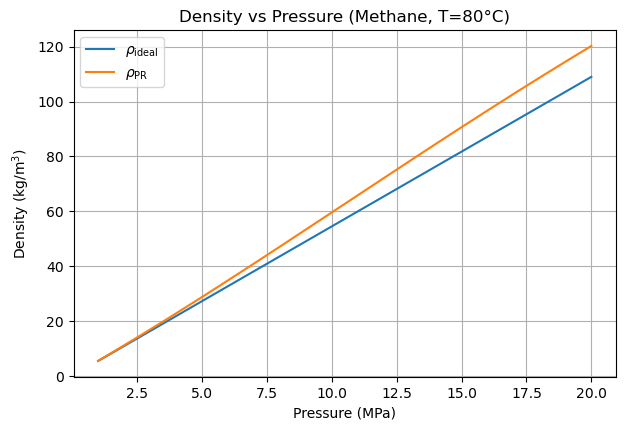

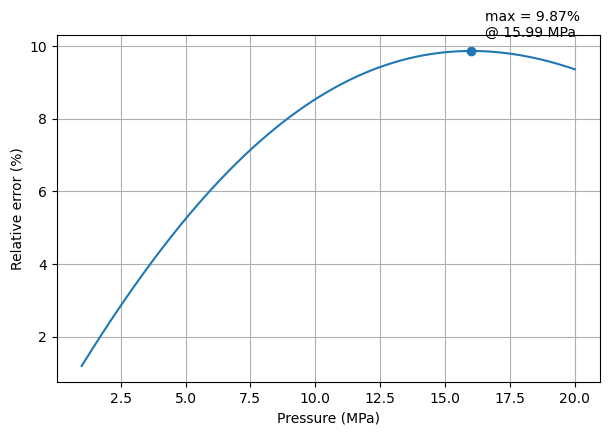

((<Figure size 700x450 with 1 Axes>,
  <Axes: title={'center': 'Density vs Pressure (Methane, T=80°C)'}, xlabel='Pressure (MPa)', ylabel='Density (kg/m$^3$)'>),
 (<Figure size 700x450 with 1 Axes>,
  <Axes: xlabel='Pressure (MPa)', ylabel='Relative error (%)'>),
 (0.09868385207535124, 15.989949748743719))

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_q1c_relative_max_error(P_range, rho_ideal, rho_pr, title="CH4 at 80°C", show=True):
    """
    Q1(c) Required by HW:
    Relative max error if ideal gas is used instead of real gas.
    
    Interpretation:
      real gas = PR (baseline/true)
      relative error = |rho_ideal - rho_PR| / rho_PR
    """
    P_range = np.asarray(P_range, dtype=float)
    rho_ideal = np.asarray(rho_ideal, dtype=float)
    rho_pr = np.asarray(rho_pr, dtype=float)
    P_MPa = P_range / 1e6

    # relative error: ideal used instead of real(PR)
    rel_err = np.abs(rho_ideal - rho_pr) / rho_pr  # dimensionless
    imax = int(np.nanargmax(rel_err))

    rel_max = rel_err[imax]
    P_at_max = P_MPa[imax]

    print(f"Relative max error = {rel_max*100:.3f}% at P = {P_at_max:.3f} MPa")

    # ---- Plot 1: densities ----
    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(P_MPa, rho_ideal, label=r'$\rho_{\mathrm{ideal}}$')
    ax1.plot(P_MPa, rho_pr,    label=r'$\rho_{\mathrm{PR}}$')
    ax1.set_xlabel("Pressure (MPa)")
    ax1.set_ylabel(r"Density (kg/m$^3$)")
    ax1.set_title(f"Density vs Pressure ({title})")
    ax1.grid(True)
    ax1.legend()

    # ---- Plot 2: relative error ----
    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    ax2.plot(P_MPa, rel_err * 100.0)
    ax2.set_xlabel("Pressure (MPa)")
    ax2.set_ylabel("Relative error (%)")  #|rho_ideal - rho_PR| / rho_PR

    ax2.grid(True)

    # mark the max error point
    ax2.scatter([P_at_max], [rel_max*100.0])
    ax2.annotate(f"max = {rel_max*100:.2f}%\n@ {P_at_max:.2f} MPa",
                 xy=(P_at_max, rel_max*100.0),
                 xytext=(10, 10),
                 textcoords="offset points")

    if show:
        plt.show()

    return (fig1, ax1), (fig2, ax2), (rel_max, P_at_max)


plot_q1c_relative_max_error(P_range, rho_ideal, rho_pr, title="Methane, T=80°C")



##  Problem 2



### Fugacity (definition)
For component $i$, fugacity $f_i$ is defined so that the chemical potential has the same form as an ideal-gas expression:
$$
\mu_i(T,P,\mathbf{x}) = \mu_i^\circ(T) + RT\ln\left(\frac{f_i}{P^\circ}\right)
$$
In a mixture (vapor or liquid), we write
$$
f_i = \phi_i x_i P \quad (\text{liquid}), \qquad f_i = \phi_i y_i P \quad (\text{vapor}),
$$
where $\phi_i$ is the **fugacity coefficient**.

### Phase equilibrium (VLE)
At equilibrium:
$$
f_i^{(L)} = f_i^{(V)} \;\;\Rightarrow\;\; x_i \phi_i^{(L)} P = y_i \phi_i^{(V)} P
$$
Define the **partition coefficient** (K-value):
$$
K_i \equiv \frac{y_i}{x_i} = \frac{\phi_i^{(L)}}{\phi_i^{(V)}}.
$$

### PR EOS for mixtures (mixing rules)
For each component $i$:
$$
a_i = 0.45724\frac{R^2T_{c,i}^2}{P_{c,i}}\alpha_i,\qquad b_i = 0.07780\frac{RT_{c,i}}{P_{c,i}}
$$
$$
a_{ij}=\sqrt{a_i a_j}(1-k_{ij})
$$
$$
a_m=\sum_i\sum_j x_i x_j a_{ij},\qquad b_m=\sum_i x_i b_i
$$
and
$$
A=\frac{a_m P}{R^2T^2},\qquad B=\frac{b_m P}{RT}.
$$

### Fugacity coefficient formula (PR)
For component $i$ in a mixture:
$$
\ln\phi_i = \frac{b_i}{b_m}(Z-1)-\ln(Z-B)
-\frac{A}{2\sqrt{2}B}\left(\frac{2\sum_j x_j a_{ij}}{a_m}-\frac{b_i}{b_m}\right)
\ln\left(\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right)
$$
where:
- \(Z\) is the compressibility factor root from the PR cubic
- use **largest** real root for vapor and **smallest** real root for liquid.

Below we implement \(\phi_i\), then do a simple isothermal flash to map the two-phase envelope and discuss bubble/dew points.


In [ ]:
def pr_phi_mixture(P, T, x, comps, kij, phase="V"):
    x = np.array(x, dtype=float)
    x = x / x.sum()
    nc = len(comps)

    # component a_i, b_i
    a_i = np.zeros(nc)
    b_i = np.zeros(nc)
    for i, c in enumerate(comps):
        a_i[i], b_i[i] = pr_ai_bi(T, c["Tc"], c["Pc"], c["omega"])

    # a_ij matrix
    a_ij = np.zeros((nc, nc))
    for i in range(nc):
        for j in range(nc):
            a_ij[i, j] = np.sqrt(a_i[i] * a_i[j]) * (1.0 - kij[i, j])

    # mixing
    a_m = 0.0
    for i in range(nc):
        for j in range(nc):
            a_m += x[i] * x[j] * a_ij[i, j]
    b_m = float(np.dot(x, b_i))

    A = a_m * P / (R**2 * T**2)
    B = b_m * P / (R * T)

    roots = pr_Z_roots(A, B)
    if len(roots) == 0:
        return np.full(nc, np.nan), np.nan, dict(A=A, B=B)

    Z = roots[-1] if phase.upper().startswith("V") else roots[0]

    sqrt2 = np.sqrt(2.0)
    ln_term = np.log((Z + (1 + sqrt2) * B) / (Z + (1 - sqrt2) * B))

    lnphi = np.zeros(nc)
    for i in range(nc):
        sum_x_aij = float(np.dot(x, a_ij[i, :]))
        lnphi[i] = (b_i[i] / b_m) * (Z - 1) - np.log(Z - B) \
                   - (A / (2 * sqrt2 * B)) * ((2 * sum_x_aij / a_m) - (b_i[i] / b_m)) * ln_term

    return np.exp(lnphi), Z, dict(A=A, B=B, a_m=a_m, b_m=b_m, a_i=a_i, b_i=b_i, a_ij=a_ij, roots=roots)

def K_wilson(P, T, comp):
    Pc = comp["Pc"]
    Tc = comp["Tc"]
    w = comp["omega"]
    return (Pc / P) * np.exp(5.373 * (1 + w) * (1 - Tc / T))

def rachford_rice_beta(z, K, tol=1e-10, maxit=200):
    z = np.array(z, dtype=float)
    z = z / z.sum()
    K = np.array(K, dtype=float)

    def f(beta):
        return np.sum(z * (K - 1.0) / (1.0 + beta * (K - 1.0)))

    f0 = f(0.0)
    f1 = f(1.0)

    if f0 < 0 and f1 < 0:
        return 0.0, False  # all liquid
    if f0 > 0 and f1 > 0:
        return 1.0, False  # all vapor

    # bisection for beta in [0, 1]
    a, b = 0.0, 1.0
    fa, fb = f0, f1
    for _ in range(maxit):
        m = 0.5 * (a + b)
        fm = f(m)
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
        if abs(b - a) < tol:
            break

    return 0.5 * (a + b), True

def pr_flash_isothermal(P, T, z, comps, kij, maxit=80, tol=1e-8):
    z = np.array(z, dtype=float)
    z = z / z.sum()
    nc = len(comps)

    K = np.array([K_wilson(P, T, c) for c in comps])

    for it in range(maxit):
        beta, has_two_phase = rachford_rice_beta(z, K)

        if not has_two_phase:
            # single phase region
            return dict(two_phase=False, beta=beta, x=z.copy(), y=z.copy(), K=K.copy(), it=it)

        x = z / (1.0 + beta * (K - 1.0))
        y = K * x
        x = x / x.sum()
        y = y / y.sum()

        phiL, ZL, _ = pr_phi_mixture(P, T, x, comps, kij, phase="L")
        phiV, ZV, _ = pr_phi_mixture(P, T, y, comps, kij, phase="V")

        K_new = np.maximum(phiL / phiV, 1e-12)

        if np.max(np.abs(K_new / K - 1.0)) < tol:
            return dict(two_phase=True, beta=beta, x=x, y=y, K=K_new, ZL=ZL, ZV=ZV, phiL=phiL, phiV=phiV, it=it)

        # damping
        K = 0.5 * K + 0.5 * K_new

    return dict(two_phase=True, beta=beta, x=x, y=y, K=K, it=maxit, converged=False)

# mixture setup
comps = [CO2, CH4]
kij = np.array([[0.0, 0.12],
                [0.12, 0.0]])
z = np.array([0.5, 0.5])


### Bubble point & dew point at **T = 80°C**

Both CH₄ and CO₂ have critical temperatures **below 80°C** (190.65 K and 304.15 K).  
Therefore, **at 80°C the mixture is expected to be supercritical (single-phase)** — i.e., the T=80°C line will not intersect the two-phase envelope.

We confirm this by scanning pressure and checking whether the isothermal flash finds a two-phase solution.


In [ ]:
# Check if any two-phase region exists at T=80°C over a wide pressure range
P_scan = np.logspace(np.log10(0.1e6), np.log10(100e6), 80)  # 0.1–100 MPa
two_phase_flags = []
betas = []

for P in P_scan:
    out = pr_flash_isothermal(P, T_fixed, z, comps, kij)
    two_phase_flags.append(out["two_phase"])
    betas.append(out["beta"])

any(two_phase_flags), (min(betas), max(betas))


If the output above shows `False`, then **no VLE (no bubble/dew points)** is predicted at 80°C by PR EOS for this mixture — the system remains single-phase in 0.1–100 MPa.

Next we **draw a P–T diagram** (two-phase envelope) by repeating the flash scan at multiple temperatures and extracting the pressure range where a two-phase solution exists.


In [ ]:
def envelope_by_scanning(z, comps, kij, T_list, Pmin=0.1e6, Pmax=50e6, nP=120):
    Ps = np.logspace(np.log10(Pmin), np.log10(Pmax), nP)
    out_rows = []
    for T in T_list:
        betas = []
        flags = []
        for P in Ps:
            r = pr_flash_isothermal(P, T, z, comps, kij)
            flags.append(r["two_phase"])
            betas.append(r["beta"])

        flags = np.array(flags, dtype=bool)
        if not np.any(flags):
            continue

        idx = np.where(flags)[0]
        i0, i1 = idx[0], idx[-1]

        # Approximate dew and bubble pressures by the edges of the two-phase interval
        P_dew = Ps[i0]   # first pressure where two-phase appears (dew boundary)
        P_bub = Ps[i1]   # last pressure where two-phase appears (bubble boundary)

        out_rows.append((T, P_dew, P_bub))
    return pd.DataFrame(out_rows, columns=["T_K", "P_dew_Pa", "P_bubble_Pa"])

T_list = np.arange(200, 275, 5)  # K (enough to capture the envelope for this mixture)
env = envelope_by_scanning(z, comps, kij, T_list)

env


In [ ]:
# Plot P–T diagram (dew and bubble curves)
plt.figure()
plt.plot(env["T_K"], env["P_dew_Pa"]/1e6, marker="o", label="Dew line (approx)")
plt.plot(env["T_K"], env["P_bubble_Pa"]/1e6, marker="o", label="Bubble line (approx)")

# Mark T=80°C line (353.15 K)
plt.axvline(T_fixed, linestyle="--", label="T = 80°C (353.15 K)")

plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (MPa)")
plt.title("CH4–CO2 (zCO2=0.5, zCH4=0.5) phase envelope by PR EOS (scan-based)")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation

- The plotted envelope (dew and bubble lines) indicates the **two-phase region** at temperatures where VLE exists.
- The vertical line at **T = 353.15 K (80°C)** is far to the right of the two-phase envelope, confirming the mixture is **single-phase** at 80°C (so bubble/dew points do not exist at this temperature).

> If your instructor expects a bubble/dew at 80°C anyway, the correct thermodynamic interpretation is that you can still discuss “dense vs gas-like” behavior at high pressure, but there is **no first-order phase boundary** above critical temperature.


---
## Appendix: quick “report-style” outputs


In [ ]:
print("=== Part 1 (methane, T=80°C) ===")
print(f"Max relative density error (ideal vs PR) over 1–20 MPa: {max_err:.4%}")
print(f"Occurs near P ≈ {P_at_max:.2f} MPa, where PR Z ≈ {Z_at_max:.4f}")
display(tbl)

print("\n=== Part 2 (mixture, zCO2=zCH4=0.5, kij=0.12) ===")
print("Any two-phase solution at T=80°C within 0.1–100 MPa? ->", any(two_phase_flags))
display(env)
